<a href="https://colab.research.google.com/github/BrandosQuest/CyberMediaProject/blob/master/HPS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install musdb soundfile

In [16]:
import numpy as np
import librosa
import scipy.ndimage
import IPython.display as ipd
import matplotlib.pyplot as plt
import soundfile as sf
import musdb
import os

In [18]:
noisy = False

mus = musdb.DB(download=True)
track = mus[23]

choice = input("Do you want to load a noisy track? (y/n): ")

if choice.lower() == "y":
    noisy_path = './songs/testSample_noisy.wav'
    if os.path.exists(noisy_path):
        print("Loading noisy track")
        x, sr = sf.read(noisy_path)
    else:
        print(f"'{noisy_path}' not found!")
        print("Generate the file before running this notebook! Using default track instead.")
        x = track.audio
        sr = track.rate
elif choice.lower() == "n":
    print("Loading clean track")
    x = track.audio
    sr = track.rate
else:
    print("Invalid choice. Loading original track")
    x = track.audio
    sr = track.rate

if x.ndim > 1:
    x = np.mean(x, axis=1)

print(f"Loaded! Length: {len(x)/sr:.2f} seconds")

Do you want to load a noisy track? (y/n):  y


Loading noisy track
Loaded! Length: 6.80 seconds


In [19]:
def apply_stft(n_fft: int, hop_length: int, x: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
  '''
  Applies stft to the original audio.

  Args:
    n_fft: The number of FFT components. This is also the length of the windowed signal.
           The number of rows in the STFT matrix is n_fft // 2 + 1.
    hop_length: The number of samples between successive STFT columns.
    x: The audio time series (input signal).

  Returns:
    X: STFT matrix of the input signal.
    Y: Power spectrogram (magnitude squared of X).
  '''
  X = librosa.stft(x, n_fft=n_fft, hop_length=hop_length)

  Y = np.abs(X)**2

  return X, Y

In [20]:
def apply_filters(L_h: int, L_p: int, Y: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
  '''
  Applies median filters to the power spectrogram Y to separate harmonic and percussive components.

  Args:
    L_h: Length of the horizontal median filter (for harmonic components).
    L_p: Length of the vertical median filter (for percussive components).
    Y: Power spectrogram (magnitude squared of the STFT matrix).

  Returns:
    Y_tilde_h: Filtered spectrogram for harmonic components.
    Y_tilde_p: Filtered spectrogram for percussive components.
  '''
  Y_tilde_h = scipy.ndimage.median_filter(Y, size=(1, L_h))

  Y_tilde_p = scipy.ndimage.median_filter(Y, size=(L_p, 1))

  return Y_tilde_h, Y_tilde_p

In [21]:
import numpy as np

def apply_mask(mask_type: str, X: np.ndarray, Y_tilde_h: np.ndarray, Y_tilde_p: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
  '''
  Applies either soft or binary masks to the STFT matrix X to separate harmonic and percussive components.

  Args:
    mask_type: A string indicating the type of mask to apply ('soft' or 'binary').
    X: The original STFT.
    Y_tilde_h: The filtered spectrogram for harmonic components.
    Y_tilde_p: The filtered spectrogram for percussive components.

  Returns:
    X_h: The STFT matrix for the harmonic component (masked).
    X_p: The STFT matrix for the percussive component (masked).
  '''
  epsilon = 1e-10

  if (mask_type == "soft"):
    # soft masks
    M_h = (Y_tilde_h + (epsilon / 2)) / (Y_tilde_h + Y_tilde_p + epsilon)
    M_p = (Y_tilde_p + (epsilon / 2)) / (Y_tilde_h + Y_tilde_p + epsilon)
  else:
    # binary masks
    M_h = np.where(Y_tilde_h >= Y_tilde_p, 1, 0)
    M_p = np.where(Y_tilde_p > Y_tilde_h, 1, 0)

  X_h = M_h * X
  X_p = M_p * X

  return X_h, X_p

In [22]:
n_fft = 2048
hop_length = 512
L_h = 31
L_p = 31
mask_type = ""

X, Y = apply_stft(n_fft, hop_length, x)

Y_tilde_h, Y_tilde_p = apply_filters(L_h, L_p, Y)

X_h, X_p = apply_mask(mask_type, X, Y_tilde_h, Y_tilde_p)

x_h = librosa.istft(X_h, hop_length=hop_length, length=len(x))
x_p = librosa.istft(X_p, hop_length=hop_length, length=len(x))


print("Separation Complete!")

Separation Complete!


In [23]:
print("Original Audio:")
display(ipd.Audio(x, rate=sr))

print("Harmonic Component (x^h):")
display(ipd.Audio(x_h, rate=sr))
print("Percussive Component (x^p):")
display(ipd.Audio(x_p, rate=sr))

Original Audio:


Harmonic Component (x^h):


Percussive Component (x^p):


In [24]:
!mkdir output
!mkdir output/hps

A subdirectory or file output already exists.
The syntax of the command is incorrect.


In [25]:
#saving outputs

sf.write("./output/hps/hps_harmonic.wav", x_h.T, sr, format='WAV')
sf.write("./output/hps/hps_percussive.wav", x_p.T, sr, format='WAV')
print("saved!")

saved!


In [26]:
# Complex spectrograms (masked) conversion to power spectrograms (without phase)
Y_h_final = np.abs(X_h)**2
Y_p_final = np.abs(X_p)**2

# Decibel conversion: 10*np.log10(Y/ref)
D_orig = librosa.power_to_db(Y, ref=np.max(Y))
D_h = librosa.power_to_db(Y_h_final, ref=np.max(Y_h_final))
D_p = librosa.power_to_db(Y_p_final, ref=np.max(Y_p_final))

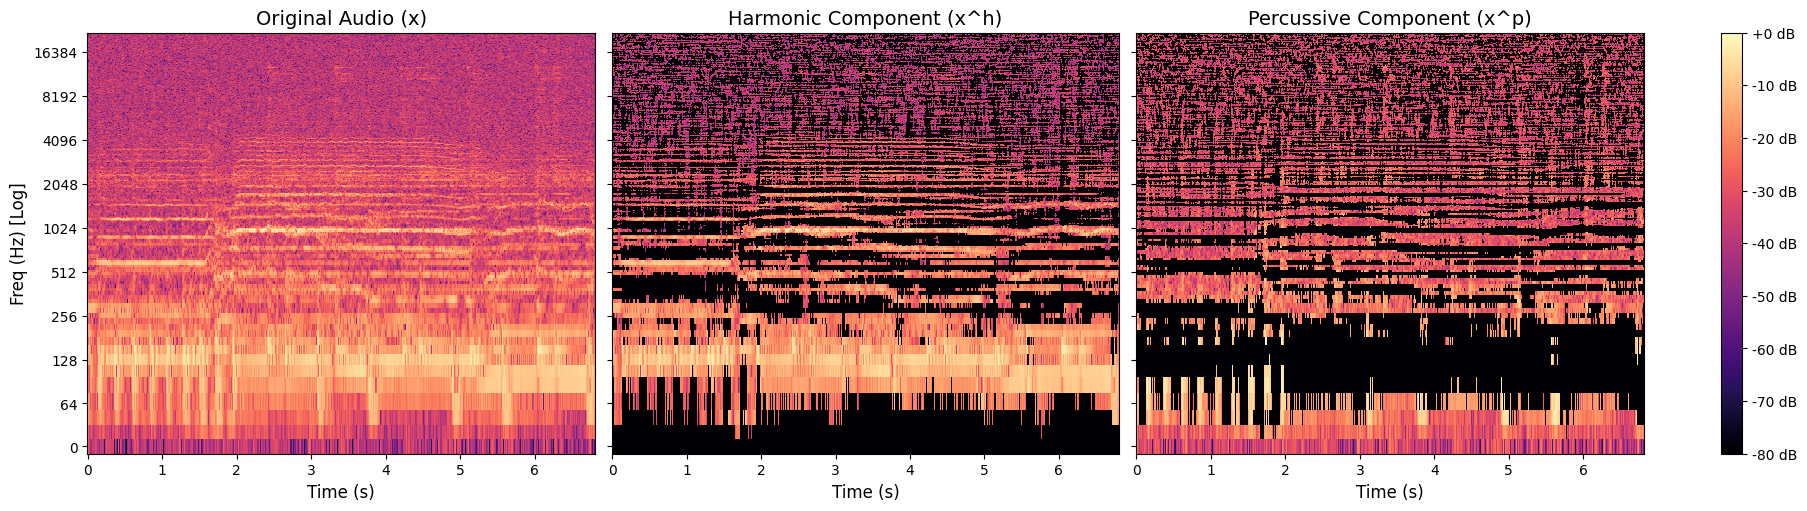

In [27]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(18, 5), sharex=True, sharey=True, layout='constrained')

specshow_kwargs = dict(sr=sr, hop_length=hop_length, x_axis='time', y_axis='log', cmap='magma')

img1 = librosa.display.specshow(D_orig, ax=ax[0], **specshow_kwargs)
ax[0].set_title('Original Audio (x)', fontsize=14)
ax[0].set_ylabel('Freq (Hz) [Log]', fontsize=12)

img2 = librosa.display.specshow(D_h, ax=ax[1], **specshow_kwargs)
ax[1].set_title('Harmonic Component (x^h)', fontsize=14)
ax[1].set_ylabel('')

img3 = librosa.display.specshow(D_p, ax=ax[2], **specshow_kwargs)
ax[2].set_title('Percussive Component (x^p)', fontsize=14)
ax[2].set_ylabel('')

fig.colorbar(img1, ax=ax, format="%+2.0f dB")

for a in ax:
    a.set_xlabel('Time (s)', fontsize=12)

plt.show()